# Spornado Disease Risk — Prediction Model Demo

**Purpose**: Demonstrate the production training pipeline and inference API using `src/`.  
**Audience**: Engineers and data scientists reviewing or extending the model.  
**Relation to production code**: This notebook *calls the same code that runs in production*. It does **not** reimplement the pipeline — all logic lives in `src/`.

## Contents
1. Setup & Configuration
2. Feature Engineering Preview
3. Train Per-Crop Models
4. Model Performance Summary
5. Threshold Visualisation
6. Single-Observation Prediction
7. Batch Prediction

### Pipeline recap
```
Raw CSV
  src.features.build_features()       <- normalise, dates, rolling stats
    src.build_crop_models.train_all_crops()
      TimeSeriesSplit CV + Pipeline(Imputer->Scaler->LogisticRegression)
        find_optimal_threshold()       <- recall-constrained, not 0.5
          models/*.pkl + models/*_thresholds.json
            src.predict.Predictor.predict()  <- inference
```

> **Recall constraint**: The deployment threshold is chosen to catch >= 90% of real outbreaks
> (configurable via `model.min_recall` in `config/config.yaml`).
> A missed outbreak costs a crop; a false alarm costs a spray — asymmetric costs
> drive a lower-than-0.5 threshold.

## 1. Setup & Configuration

In [174]:
import sys, warnings, json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Project root on sys.path (works from notebooks/ or project root)
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config_loader import load as load_config
from src.features import build_features, get_feature_columns, TARGET_COL
from src.build_crop_models import train_all_crops, risk_label, find_optimal_threshold
from src.predict import Predictor

cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')
DATA_RAW   = PROJECT_ROOT / cfg['paths']['data_merged']
MODELS_DIR = PROJECT_ROOT / cfg['paths']['models_dir']
DIR_OUT    = PROJECT_ROOT / 'outputs'
DIR_OUT.mkdir(exist_ok=True)

print('Config loaded.')
print(f'  min_recall         : {cfg["model"]["min_recall"]}')
print(f'  medium_band_factor : {cfg["model"]["medium_band_factor"]}')
print(f'  cv_folds           : {cfg["model"]["cv_folds"]}')
print(f'  Data path          : {DATA_RAW}')
print(f'  Models dir         : {MODELS_DIR}')


Config loaded.
  min_recall         : 0.9
  medium_band_factor : 0.7
  cv_folds           : 5
  Data path          : C:\Users\Admin\Desktop\RnD\spornado_risk_model\data\raw\spornado_weather_spore_data.csv
  Models dir         : C:\Users\Admin\Desktop\RnD\spornado_risk_model\models


**Note.** `min_recall` (here 0.9) is a product choice: the threshold search keeps lowering the probability cut until recall on the time-ordered test set hits that floor, then fine-tunes bands. The sections below show whether that contract is met in practice—e.g. the champion recall bars sit at or above the red line for each crop when this notebook was last run.

CV fold means are **in-sample** along the training timeline; only the final holdout simulates “score today, truth later.”


## 2. Feature Engineering Preview

All transformations are handled by `src.features.build_features()`.
This cell loads the raw CSV and runs the full feature pipeline so we can
inspect the resulting feature matrix before training.

> **Spore count is excluded from features.**  Using it would be target leakage — the device labels a trap positive/negative
> *based on* spore detection.  Weather signals alone allow predictions
> *before* a trap is read.

In [175]:
raw = pd.read_csv(DATA_RAW, low_memory=False)
print(f'Raw shape: {raw.shape}')

df = build_features(raw, cfg)
print(f'After feature engineering: {df.shape}')
print()
print('Target balance (all crops):')
print(df[TARGET_COL].value_counts().rename({0: 'negative', 1: 'positive'}).to_string())


Raw shape: (3784, 26)


After feature engineering: (3504, 56)

Target balance (all crops):
disease_present
positive    2546
negative     958


In [176]:
feature_cols = get_feature_columns(cfg, df)
weather  = cfg['features']['weather']
temporal = cfg['features']['temporal']
rolling  = [c for c in feature_cols if 'roll' in c]

print(f'Total features : {len(feature_cols)}')
print(f'  Weather  ({len(weather):2d}) : {weather}')
print(f'  Temporal ({len(temporal):2d}) : {temporal}')
print(f'  Rolling  ({len(rolling):2d}) : {rolling[:4]} ...')
print()
print(df[feature_cols].describe().round(2))


Total features : 37
  Weather  ( 7) : ['temperature_min_c', 'temperature_max_c', 'temperature_mean_c', 'humidity_max_percent', 'precipitation_mm', 'wind_speed_max_kmh', 'dew_point_min_c']
  Temporal ( 3) : ['month', 'day_of_year', 'week_of_year']
  Rolling  (24) : ['temperature_max_c_roll3mean', 'temperature_max_c_roll3max', 'temperature_max_c_roll5mean', 'temperature_max_c_roll5max'] ...

       temperature_min_c  temperature_max_c  temperature_mean_c  \
count            3478.00            3478.00             3478.00   
mean               18.04              27.31               22.59   
std                 3.80               3.84                3.56   
min                 4.70               6.90                5.90   
25%                15.40              25.00               20.00   
50%                18.50              27.80               23.10   
75%                21.00              29.80               24.90   
max                26.10              36.00               31.00   

   

**Note.** In the run saved with this notebook, `build_features` shrinks the CSV and the printed target mix is heavily positive (most traps are in-season placements). That inflates naive accuracy—judge the models on ROC AUC and recall/precision at the operating threshold, not overall hit rate.

Feature columns bundle weather, calendar, trap geography, disease identity dummies, and rolling statistics—those rolls need deployment history; sparse traps produce NaNs imputed during training, which is why single-row demos sometimes list many “missing” roll columns but still score.


## 3. Train Per-Crop Models

Calls `src.build_crop_models.train_all_crops()` which:
- Splits data chronologically (no future leakage)
- Runs 5-fold `TimeSeriesSplit` cross-validation on the training set
- Fits `Pipeline(SimpleImputer -> StandardScaler -> LogisticRegression)`
- Finds the recall-constrained threshold via `precision_recall_curve`
- Saves `.pkl` and `_thresholds.json` for each crop

> **Runtime**: ~10-30 seconds per crop on a laptop (n_jobs=1).

In [177]:
import logging
logging.basicConfig(level=logging.WARNING)  # suppress INFO during notebook run

results_df = train_all_crops(
    data_path=str(DATA_RAW),
    cfg=cfg,
)

display_cols = [
    'crop', 'train_samples', 'test_samples',
    'cv_auc_mean', 'cv_auc_std',
    'test_auc', 'test_f1', 'test_precision', 'test_recall',
    'threshold_optimal', 'threshold_achieved_recall',
]
print(results_df[display_cols].to_string(index=False))

   crop  train_samples  test_samples  cv_auc_mean  cv_auc_std  test_auc  test_f1  test_precision  test_recall  threshold_optimal  threshold_achieved_recall
   Corn           2021           506     0.893754    0.056208  0.834210 0.883553        0.849885     0.920000             0.1774                     0.9484
   Corn           2021           506     0.907068    0.054355  0.797901 0.856404        0.887399     0.827500             0.1667                     0.9065
   Corn           2021           506     0.873711    0.062665  0.705200 0.869767        0.813043     0.935000             0.3125                     0.9839
Soybean            463           116     0.931588    0.036260  0.911285 0.923077        0.947368     0.900000             0.3069                     0.9518
Soybean            463           116     0.641450    0.176529  0.661979 0.763006        0.709677     0.825000             0.4296                     0.9157
Soybean            463           116     0.832748    0.080022  0

**Note.** Read the training table **grouped by crop**: three rows per crop are the standard triplet from `train_all_crops`—**LogisticRegression (baseline)**, **XGBoost (weather)**, and **LogisticRegression (temporal fallback)**. In this notebook’s output, **Corn** LR reaches test_auc ≈ **0.834** versus XGB ≈ **0.798** on the same holdout—LR ranks outbreaks better here. **Soybean** LR is strongest on both AUC (~0.91) and threshold recall (~0.95). **Wheat** shows the widest spread: one XGB row bottoms near **0.49** test AUC while LR stays near **0.68**, which is why champion selection ends up on LR for every crop in the decision table.

`threshold_optimal` near **0.17–0.31** is typical after recall tuning—far below 0.5—so probability outputs cluster high before anyone flags HIGH risk.

Re-run after any data refresh so these rows match `models/*.pkl`.


## 4. Model Performance Summary

Key distinction: **all metrics are computed at the deployment threshold**
(not the sklearn default of 0.5).  This is what matters in production.

| Metric | Meaning |
|---|---|
| `test_auc` | Threshold-independent discrimination (ROC area) |
| `test_recall` | Fraction of real outbreaks caught — must be >= `min_recall` |
| `test_precision` | Fraction of HIGH alerts that are real outbreaks |
| `threshold_optimal` | The actual cut-off used at inference time |

In [178]:
# ── Per-crop champion bar chart ───────────────────────────────────────────────
# Selection policy (matches Section 6 and Section 7b exactly):
#   recall gate (>= min_recall) -> highest operating_recall
#   -> tie-break by operating_precision -> AUC tie-break
# Source: results CSV — model_selection.json is NOT used here.
# Candidates: "LogisticRegression (baseline)" and "XGBoost (weather)" only.
# ─────────────────────────────────────────────────────────────────────────────
results_path = MODELS_DIR / "model_performance_results.csv"
res = pd.read_csv(results_path)
target_recall = float(cfg["model"]["min_recall"])

WEATHER_TYPES = {"LogisticRegression (baseline)", "XGBoost (weather)"}
compare = res[res["model_type"].isin(WEATHER_TYPES)].copy()
compare["operating_recall"] = compare["threshold_achieved_recall"].fillna(compare["test_recall"])
compare["operating_precision"] = compare["threshold_achieved_precision"].fillna(compare["test_precision"])
compare["cv_test_auc_gap"] = compare["cv_auc_mean"] - compare["test_auc"]

champion_rows = []
for crop, grp in compare.groupby("crop"):
    g = grp.copy()
    g["meets_recall"] = g["operating_recall"] >= target_recall

    feasible = g[g["meets_recall"]]
    pool = feasible if not feasible.empty else g

    winner = pool.sort_values(
        ["operating_recall", "operating_precision", "test_auc"],
        ascending=[False, False, False],
    ).iloc[0]
    champion_rows.append(winner)

perf_df = pd.DataFrame(champion_rows).sort_values("crop").reset_index(drop=True)
perf_df["operating_recall"] = perf_df["threshold_achieved_recall"].fillna(perf_df["test_recall"])
perf_df["cv_test_auc_gap"] = perf_df["cv_auc_mean"] - perf_df["test_auc"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Per-Crop Champion Performance  (recall gate → precision → AUC selection)",
    fontsize=13, fontweight="bold",
)

perf_df["operating_precision"] = perf_df["threshold_achieved_precision"].fillna(perf_df["test_precision"])

metrics = ["test_auc", "operating_recall", "operating_precision"]
labels  = ["ROC AUC", "Recall (outbreak catch rate)", "Precision (alert accuracy)"]
colors  = ["#2980b9", "#e74c3c", "#27ae60"]

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    bars = ax.bar(perf_df["crop"], perf_df[metric], color=color, alpha=0.85, edgecolor="black")
    ax.set_title(label)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    if metric == "operating_recall":
        ax.axhline(target_recall, color="red", linestyle="--", linewidth=1.5,
                   label=f"min_recall={target_recall}")
        ax.legend(fontsize=8)
    for bar, val in zip(bars, perf_df[metric]):
        ax.annotate(
            f"{val:.3f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            textcoords="offset points", xytext=(0, 4),
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.5),
        )

plt.tight_layout()
plt.savefig(DIR_OUT / "07_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07_model_performance.png")
print()
print("Decision table (champions):")
print(perf_df[["crop", "model_type", "operating_recall", "operating_precision", "cv_test_auc_gap"]].to_string(index=False))


Saved: 07_model_performance.png

Decision table (champions):
   crop                    model_type  operating_recall  operating_precision  cv_test_auc_gap
   Corn LogisticRegression (baseline)            0.9484               0.8329         0.059544
Soybean LogisticRegression (baseline)            0.9518               0.9753         0.020303
  Wheat LogisticRegression (baseline)            1.0000               0.7593         0.049046


**Note.** The triple-panel figure applies **only** to champions selected from `model_performance_results.csv` (LR vs XGB weather candidates). **ROC AUC** (blue bars): in this run **Soybean ~0.91** leads, **Corn ~0.83** is mid, **Wheat ~0.68** is weakest—ranking quality is crop-dependent and Wheat suffers from fewer test rows (**n≈80**). **Operating recall** (red): all three sit **at/above** the `min_recall` dashed line (~**0.95–1.0** here), so the recall gate is satisfied. **Operating precision** (green): **Soybean ~0.98** is excellent (few wasted escalations); **Corn ~0.83** is workable; **Wheat ~0.76** is noticeably looser.

**cv_test_auc_gap**: Corn shows the largest gap (~**0.06**), Soybean the smallest (~**0.02**). That pattern often appears when the holdout season is harder or shorter than the CV folds—monitor Wheat especially because low AUC plus small **n_test** makes variance wide.

Production routing uses `model_selection.json`; align it with this CSV if you want parity between notebook analytics and deployment.


## 5. Threshold Visualisation

Each crop has three risk zones derived from the recall-constrained threshold:

```
  0.0 ---- low_max --------- high_min (= optimal) ---- 1.0
     LOW (safe)  MEDIUM (uncertain)  HIGH (alert)
```

`low_max = optimal x medium_band_factor`
The uncertain zone is proportional to the decision boundary, not a fixed offset.

In [179]:
ncrop = len(results_df)
fig, axes = plt.subplots(1, ncrop, figsize=(5 * ncrop, 4))
if ncrop == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, results_df.iterrows()):
    low_max  = row['threshold_low_max']
    high_min = row['threshold_high_min']  # == threshold_optimal

    ax.barh([''], [low_max],             left=0,        color='#2ecc71', alpha=0.7, label='LOW')
    ax.barh([''], [high_min - low_max],  left=low_max,  color='#f39c12', alpha=0.7, label='MEDIUM')
    ax.barh([''], [1 - high_min],        left=high_min, color='#e74c3c', alpha=0.7, label='HIGH')
    ax.axvline(high_min, color='#c0392b', linewidth=2.5)
    ax.axvline(low_max,  color='#27ae60', linewidth=1.5, linestyle='--')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Risk probability')
    ax.set_title(
        f"{row['crop']}\n"
        f"Threshold={high_min:.3f}  Recall={row['threshold_achieved_recall']:.1%}"
        f"  Precision={row['test_precision']:.1%}",
        fontsize=10
    )
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Risk Zones per Crop (recall-constrained thresholds)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Note.** Each horizontal strip is probability space: green **LOW**, amber **MEDIUM**, red **HIGH**, with the thick tick at the **operating** threshold (Corn ~**0.18**, Soybean ~**0.31**, Wheat ~**0.28** in the saved training table—exact ticks follow the latest `results_df`). Because thresholds are recall-driven, most deployments spend probability mass on the right half of the bar—don’t expect a “balanced” 0.5 cut.

Subtitle precision comes from the training-run CSV row for that champion; if Section 7b shows slightly different recall/precision, trust the **reconstructed-test** numbers under the confusion matrices—they re-score the saved model on the same held-out rows used for the plots.


## 6. Weather Models Head-to-Head (Logistic vs XGBoost)

This section compares the two weather-capable candidates on the same chronological hold-out:

- `LogisticRegression (baseline)` (weather features)
- `XGBoost (weather)`

Selection policy (production-grade):
1. Enforce recall gate: model must meet configured minimum recall target.
2. Among feasible models, choose higher precision at operating threshold.
3. Use AUC as tie-break.

This keeps model selection aligned with outbreak-catch business requirements while minimizing false alerts.

In [180]:
# Always reload latest metrics from disk so this section reflects the most recent retraining run.
results_path = MODELS_DIR / "model_performance_results.csv"
results_df = pd.read_csv(results_path)

compare = results_df[
    results_df["model_type"].isin(["LogisticRegression (baseline)", "XGBoost (weather)"])
].copy()
compare["operating_recall"] = compare["threshold_achieved_recall"].fillna(compare["test_recall"])
compare["operating_precision"] = compare["threshold_achieved_precision"].fillna(compare["test_precision"])
compare["cv_test_auc_gap"] = compare["cv_auc_mean"] - compare["test_auc"]

if compare.empty:
    print("No Logistic-vs-XGBoost weather comparison rows found in results_df.")
else:
    target_recall = float(cfg["model"].get("min_recall", 0.90))

    # Cleaner display labels for notebook output
    compare["model_display"] = compare["model_type"].map({
        "LogisticRegression (baseline)": "LogisticRegression",
        "XGBoost (weather)": "XGBoost",
    }).fillna(compare["model_type"])

    summary = compare[[
        "crop",
        "model_display",
        "operating_recall",
        "operating_precision",
        "cv_test_auc_gap",
    ]].sort_values(["crop", "model_display"]).reset_index(drop=True)

    print("Decision table (weather-model comparison):")
    display(summary)

    picks = []
    for crop, grp in compare.groupby("crop"):
        g = grp.copy()
        g["meets_recall_target"] = g["operating_recall"] >= target_recall

        feasible = g[g["meets_recall_target"]]
        pool = feasible if not feasible.empty else g

        # Selection policy: recall gate -> recall -> precision -> AUC
        winner = pool.sort_values(
            ["operating_recall", "operating_precision", "test_auc"],
            ascending=[False, False, False],
        ).iloc[0]

        picks.append({
            "crop": crop,
            "selected_model": winner["model_display"],
            "operating_recall": round(float(winner["operating_recall"]), 4),
            "operating_precision": round(float(winner["operating_precision"]), 4),
            "cv_test_auc_gap": round(float(winner["cv_test_auc_gap"]), 4),
        })

    picks_df = pd.DataFrame(picks).sort_values("crop").reset_index(drop=True)

    print(f"Configured minimum recall target: {target_recall:.0%}")
    print("Decision table (selected champions):")
    display(picks_df[["crop", "selected_model", "operating_recall", "operating_precision", "cv_test_auc_gap"]])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(
        data=compare,
        x="crop",
        y="threshold_achieved_recall",
        hue="model_display",
        ax=axes[0],
    )
    axes[0].axhline(target_recall, linestyle="--", linewidth=1.2, color="#e74c3c")
    axes[0].set_title("Recall at Operating Threshold")
    axes[0].set_ylabel("Recall")
    axes[0].set_xlabel("Crop")

    sns.barplot(
        data=compare,
        x="crop",
        y="threshold_achieved_precision",
        hue="model_display",
        ax=axes[1],
    )
    axes[1].set_title("Precision at Operating Threshold")
    axes[1].set_ylabel("Precision")
    axes[1].set_xlabel("Crop")

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, title="Model", loc="best")
    axes[1].legend_.remove()

    plt.tight_layout()
    plt.show()

Decision table (weather-model comparison):


,crop,model_display,operating_recall,operating_precision,cv_test_auc_gap
0,Corn,LogisticRegression,0.9484,0.8329,0.059544
1,Corn,XGBoost,0.9065,0.8949,0.109167
2,Soybean,LogisticRegression,0.9518,0.9753,0.020303
3,Soybean,XGBoost,0.9157,0.9157,-0.020529
4,Wheat,LogisticRegression,1.0000,0.7593,0.049046
5,Wheat,XGBoost,1.0000,0.7069,0.169666


Configured minimum recall target: 90%
Decision table (selected champions):


,crop,selected_model,operating_recall,operating_precision,cv_test_auc_gap
0,Corn,LogisticRegression,0.9484,0.8329,0.0595
1,Soybean,LogisticRegression,0.9518,0.9753,0.0203
2,Wheat,LogisticRegression,1.0000,0.7593,0.0490


**Note.** Compare **paired bars** within each crop. **Corn**: LR keeps **higher operating recall** (~**0.95** vs ~**0.91**) even though XGB posts slightly higher precision in one column—the policy prefers recall first, so LR stays champion. **Soybean**: LR dominates both recall and precision versus XGB in this run (bars gap visibly). **Wheat**: both models peg recall at **1.0** at the operating point; LR wins on **precision (~0.76 vs ~0.71**) under the tie-break.

When precision curves overlap, focus on whether extra tree complexity buys enough recall to justify operational complexity—here it generally does not.


## 7. Champion Diagnostics

For each crop the **best model is selected at runtime** from the results CSV using the same
production policy enforced in Section 6:

1. **Recall gate** — only models that achieved `threshold_achieved_recall ≥ min_recall` are eligible.
2. **Highest precision** — among eligible models, the one with the fewest false alarms wins.
3. **AUC tie-break** — if precision is identical, higher AUC wins.

Each row in the figure shows:
- **Left** — confusion matrix with raw counts and row-normalised percentages, plus Recall / Precision / Specificity at the operating threshold.
- **Right** — calibration curve (quantile bins, adaptive bin count) with ECE annotation and a probability histogram inset showing the separation between negative and positive cases.


In [181]:
%matplotlib inline
import matplotlib
print("backend:", matplotlib.get_backend())

backend: inline


### 7b. Combined Diagnostics Figure

One figure, one row per crop champion. Uses the same recall-gate → precision → AUC policy
as Section 6 — `model_selection.json` is **not** consulted here, so the diagnostics always
reflect the empirically best model regardless of what the manifest says.

Crop        Model                                    CSV-AUC   CSV-Rec   CSV-Prec     thr  n_test
-----------------------------------------------------------------------------------------------
Corn        LogisticRegression (baseline)              0.834     94.8%      83.3%   0.177  506
Soybean     LogisticRegression (baseline)              0.911     95.2%      97.5%   0.307  116
Wheat       LogisticRegression (baseline)              0.680    100.0%      75.9%   0.282  80

──────────────────────────────────────────────────────────────────────
Crop        Model                                    Recall     Prec     Spec
──────────────────────────────────────────────────────────────────────
Corn        LogisticRegression (baseline)             92.0%    85.0%    38.7%
Soybean     LogisticRegression (baseline)             90.0%    94.7%    88.9%
Wheat       LogisticRegression (baseline)             95.8%    63.0%    15.6%
───────────────────────────────────────────────────────────────────

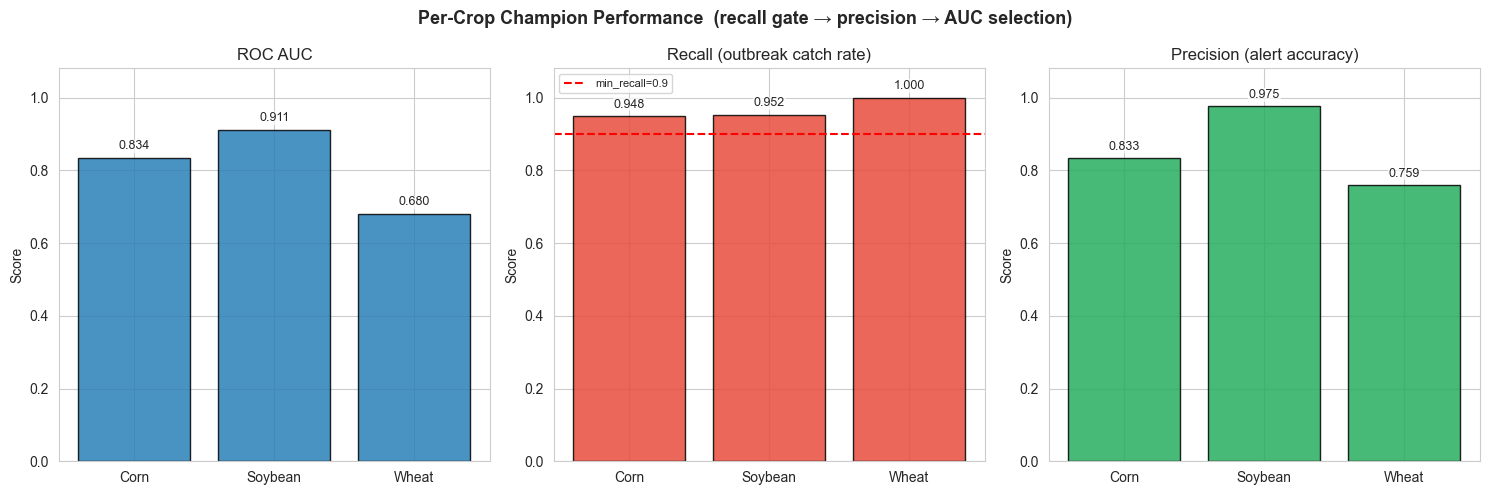

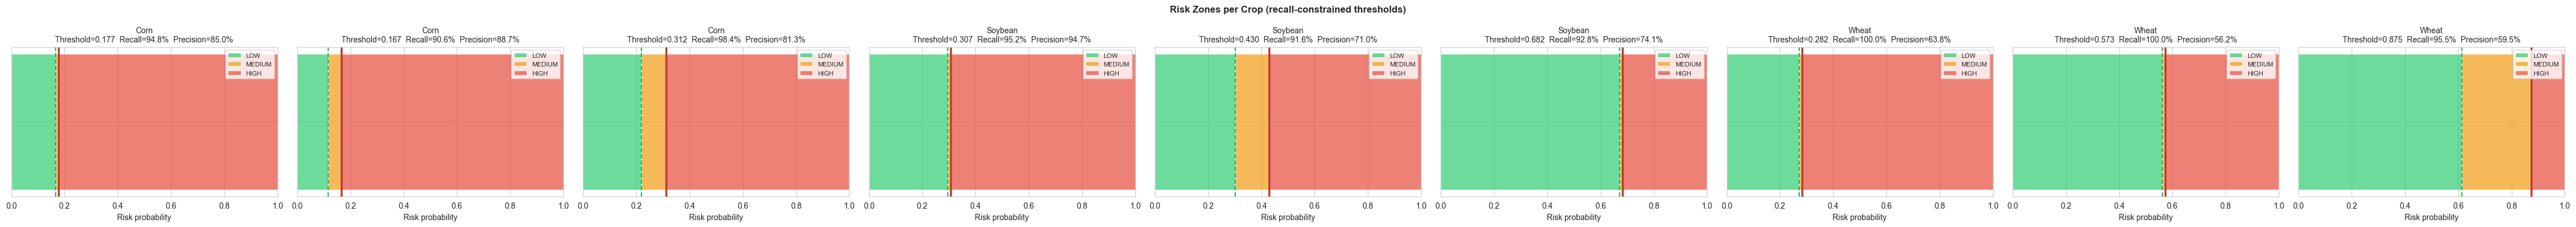

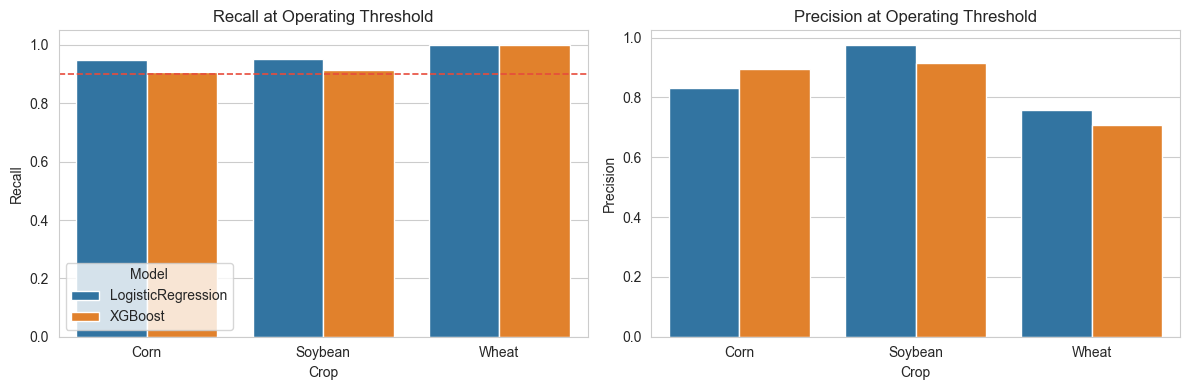

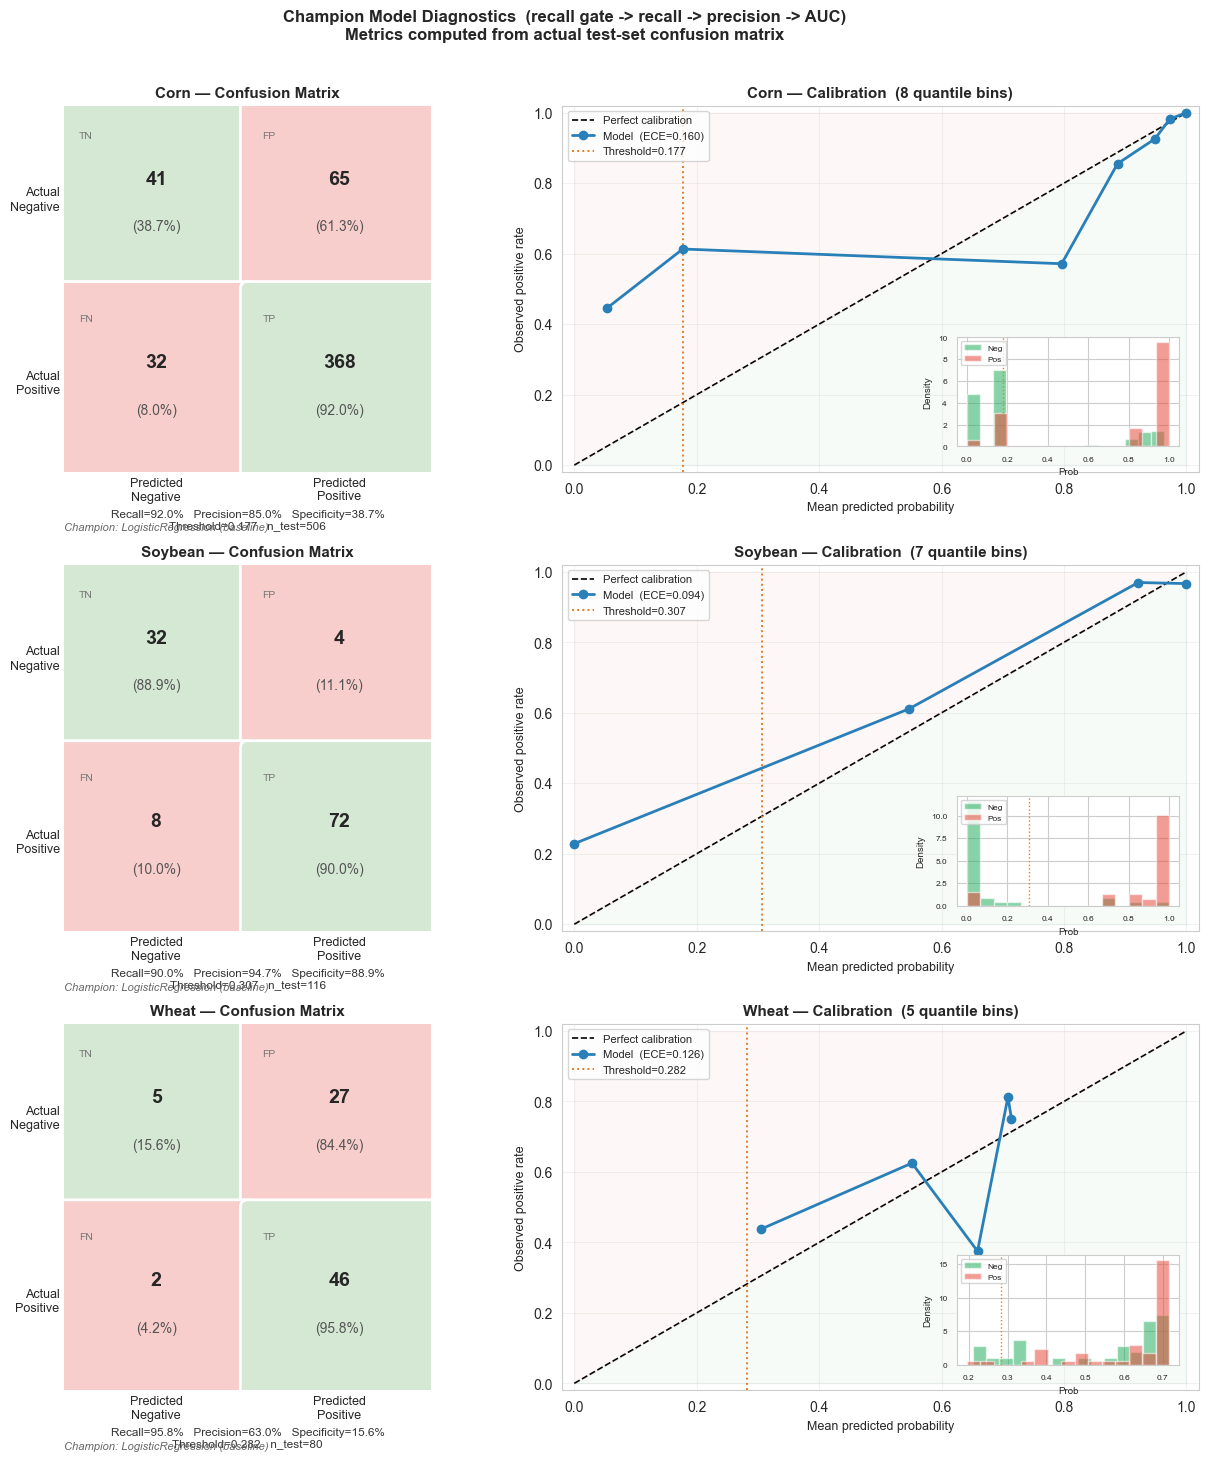


Saved: 07b_champion_diagnostics.png


In [182]:
# ── Champion Diagnostics ─────────────────────────────────────────────────────
# Selection: recall gate (>= min_recall) -> highest operating recall
# -> tie-break by operating precision -> AUC tie-break.
# Candidates: LR baseline + XGBoost weather ONLY.
# Temporal fallback is excluded — it is an inference fallback, not a champion
# candidate, and shares threshold files with the baseline which causes metric
# confusion on the reconstructed test set.
#
# Confusion matrix metrics (Recall / Precision / Specificity) are computed from
# the ACTUAL confusion matrix counts — not from the results CSV — so they are
# guaranteed to match the cells you see.
# ─────────────────────────────────────────────────────────────────────────────
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

from src.features import build_features, TARGET_COL
from src.build_crop_models import temporal_train_test_split


# ── Helpers ──────────────────────────────────────────────────────────────────

def _disease_key(name: str) -> str:
    slug = str(name).strip().lower().replace("-", " ").replace("/", " ")
    return "disease_" + "_".join(slug.split())


def _plot_confusion(ax, y_true, y_pred, crop, threshold):
    """Confusion matrix — counts + row-normalised % + metrics from actual CM."""
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Layout (rows = actual, cols = predicted):
    #   top-left  = TN (Actual Neg, Pred Neg)  → green
    #   top-right = FP (Actual Neg, Pred Pos)  → red
    #   bot-left  = FN (Actual Pos, Pred Neg)  → red
    #   bot-right = TP (Actual Pos, Pred Pos)  → green
    cell_colors = [["#d5e8d4", "#f8cecc"],
                   ["#f8cecc", "#d5e8d4"]]

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect("equal")

    for r in range(2):
        for c in range(2):
            ax.add_patch(mpatches.FancyBboxPatch(
                (c, 1 - r), 1, 1,
                boxstyle="round,pad=0.04",
                facecolor=cell_colors[r][c],
                edgecolor="white", linewidth=2, zorder=1,
            ))
            ax.text(c + 0.5, 1 - r + 0.60, f"{cm[r, c]}",
                    ha="center", va="center", fontsize=14, fontweight="bold", zorder=2)
            ax.text(c + 0.5, 1 - r + 0.34, f"({cm_pct[r, c]:.1f}%)",
                    ha="center", va="center", fontsize=10, color="#555555", zorder=2)

    # Corner labels
    for (rx, cx), lbl in [((0, 0), "TN"), ((0, 1), "FP"), ((1, 0), "FN"), ((1, 1), "TP")]:
        ax.text(cx + 0.08, 1 - rx + 0.86, lbl,
                ha="left", va="top", fontsize=7.5, color="#777777", zorder=2)

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Predicted\nNegative", "Predicted\nPositive"], fontsize=9)

    # Plot coordinates put row 0 at the TOP (y=1.5) and row 1 at the BOTTOM (y=0.5).
    # confusion_matrix row order is [Actual Negative, Actual Positive], so map labels accordingly.
    ax.set_yticks([1.5, 0.5])
    ax.set_yticklabels(["Actual\nNegative", "Actual\nPositive"], fontsize=9)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Compute metrics directly from the confusion matrix
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)     if (tp + fn) > 0  else float("nan")
    precision = tp / (tp + fp)     if (tp + fp) > 0  else float("nan")
    spec      = tn / (tn + fp)     if (tn + fp) > 0  else float("nan")

    ax.set_title(f"{crop} — Confusion Matrix", fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel(
        f"Recall={recall:.1%}   Precision={precision:.1%}   Specificity={spec:.1%}\n"
        f"Threshold={threshold:.3f}   n_test={len(y_true)}",
        fontsize=8.5, color="#333333",
    )

    return recall, precision   # expose for the print summary


def _plot_calibration(ax, y_true, y_proba, crop, threshold):
    """Calibration curve (quantile bins) + ECE + probability histogram inset."""
    n_test = len(y_true)
    n_bins = max(3, min(8, n_test // 15))

    frac_pos, mean_pred = calibration_curve(
        y_true, y_proba, n_bins=n_bins, strategy="quantile"
    )
    ece = float(np.mean(np.abs(frac_pos - mean_pred)))

    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Perfect calibration", zorder=1)
    ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, markersize=6,
            color="#2980b9", label=f"Model  (ECE={ece:.3f})", zorder=3)
    ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.04, color="#e74c3c")
    ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.04, color="#27ae60")
    ax.axvline(threshold, color="#e67e22", linewidth=1.4, linestyle=":",
               label=f"Threshold={threshold:.3f}")

    ax_in = ax.inset_axes([0.62, 0.07, 0.35, 0.30])
    ax_in.hist(y_proba[y_true == 0], bins=15, alpha=0.55, color="#27ae60",
               label="Neg", density=True)
    ax_in.hist(y_proba[y_true == 1], bins=15, alpha=0.55, color="#e74c3c",
               label="Pos", density=True)
    ax_in.axvline(threshold, color="#e67e22", linewidth=1.0, linestyle=":")
    ax_in.set_xlabel("Prob", fontsize=7)
    ax_in.set_ylabel("Density", fontsize=7)
    ax_in.tick_params(labelsize=6)
    ax_in.legend(fontsize=6, loc="upper left")

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Mean predicted probability", fontsize=9)
    ax.set_ylabel("Observed positive rate", fontsize=9)
    ax.set_title(f"{crop} — Calibration  ({n_bins} quantile bins)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)


# ── Champion selection ────────────────────────────────────────────────────────
results_path = MODELS_DIR / "model_performance_results.csv"
if not results_path.exists():
    raise FileNotFoundError(f"Results CSV not found: {results_path}\nRun Section 3 first.")

res = pd.read_csv(results_path)
target_recall = float(cfg["model"].get("min_recall", 0.90))

# Only weather-capable model types — temporal fallback excluded intentionally
WEATHER_TYPES = {"LogisticRegression (baseline)", "XGBoost (weather)"}
compare = res[res["model_type"].isin(WEATHER_TYPES)].copy()
compare["operating_recall"] = compare["threshold_achieved_recall"].fillna(compare["test_recall"])
compare["operating_precision"] = compare["threshold_achieved_precision"].fillna(compare["test_precision"])
compare["cv_test_auc_gap"] = compare["cv_auc_mean"] - compare["test_auc"]

SUFFIX_MAP = {
    "XGBoost (weather)":             "_model_weather.pkl",
    "LogisticRegression (baseline)": "_model_baseline.pkl",
}
raw_full = pd.read_csv(DATA_RAW, low_memory=False)
df_full  = build_features(raw_full, cfg)
test_size = cfg["data"]["test_size"]

champion_rows = []
for crop, grp in compare.groupby("crop"):
    g = grp.copy()
    g["meets_recall"] = g["operating_recall"] >= target_recall

    feasible = g[g["meets_recall"]]
    pool = feasible if not feasible.empty else g

    winner = pool.sort_values(
        ["operating_recall", "operating_precision", "test_auc"],
        ascending=[False, False, False],
    ).iloc[0]
    champion_rows.append(winner)

if not champion_rows:
    raise RuntimeError("No champion models found — run Section 3 first.")

# ── Build test sets + score ────────────────────────────────────────────────────
plot_data = []

print(f"{'Crop':<10}  {'Model':<38}  {'CSV-AUC':>8}  {'CSV-Rec':>8}  {'CSV-Prec':>9}  {'thr':>6}  n_test")
print("-" * 95)

for winner in champion_rows:
    crop       = winner["crop"]
    model_type = winner["model_type"]
    suffix     = SUFFIX_MAP[model_type]
    model_path = MODELS_DIR / f"{crop.lower()}{suffix}"

    if not model_path.exists():
        print(f"[SKIP] {crop} ({model_type}): model artifact missing — {model_path.name}")
        continue

    pipe = joblib.load(model_path)

    # Use row-specific deployment threshold from results CSV to avoid
    # baseline/temporal threshold-file collisions (both use *_thresholds.json).
    thr = float(winner.get("threshold_high_min", winner.get("threshold_optimal", 0.5)))
    thr = float(np.clip(thr, 0.0, 1.0))

    # Recover feature columns from the saved pipeline
    feature_cols: list[str] = []
    inner = pipe
    if hasattr(pipe, "calibrated_classifiers_"):
        try:
            inner = pipe.calibrated_classifiers_[0].estimator
        except (IndexError, AttributeError):
            pass
    for step_name in ("imputer", "scaler", "preprocessor"):
        step = getattr(inner, "named_steps", {}).get(step_name)
        if step is not None and hasattr(step, "feature_names_in_"):
            feature_cols = list(step.feature_names_in_)
            break

    if not feature_cols:
        print(f"[SKIP] {crop}: cannot recover feature columns from {model_path.name}")
        continue

    sub = df_full[df_full["crop_type"].str.strip().str.title() == crop].copy()
    if sub.empty:
        print(f"[SKIP] {crop}: no rows in dataset")
        continue

    disease_dummy_cols = [c for c in feature_cols if c.startswith("disease_")]
    if disease_dummy_cols and "test" in sub.columns:
        for col in disease_dummy_cols:
            sub[col] = 0.0
        for idx, val in sub["test"].items():
            if pd.notna(val):
                dk = _disease_key(str(val))
                if dk in disease_dummy_cols:
                    sub.at[idx, dk] = 1.0

    sub = sub.dropna(subset=["start_date", TARGET_COL])
    if len(sub) < 20:
        print(f"[SKIP] {crop}: too few rows ({len(sub)})")
        continue

    _, test_df = temporal_train_test_split(sub, "start_date", test_size)
    X_test = test_df.reindex(columns=feature_cols)
    y_test = test_df[TARGET_COL].astype(int).to_numpy()

    if len(np.unique(y_test)) < 2:
        print(f"[SKIP] {crop}: one-class test split")
        continue

    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= thr).astype(int)

    pred_pos_rate = float(y_pred.mean())
    if pred_pos_rate in (0.0, 1.0):
        print(f"[WARN] {crop}: degenerate predictions at threshold={thr:.3f} (pred_pos_rate={pred_pos_rate:.1%})")

    print(
        f"{crop:<10}  {model_type:<38}  "
        f"{winner['test_auc']:>8.3f}  "
        f"{winner['threshold_achieved_recall']:>8.1%}  "
        f"{winner['threshold_achieved_precision']:>9.1%}  "
        f"{thr:>6.3f}  {len(y_test)}"
    )
    plot_data.append((crop, model_type, y_test, y_pred, y_proba, thr))

# ── Plot ─────────────────────────────────────────────────────────────────────
if not plot_data:
    print("\nNothing to plot — check model artifacts.")
else:
    n = len(plot_data)
    fig, axes = plt.subplots(n, 2, figsize=(13, 4.8 * n))
    if n == 1:
        axes = np.array([axes])

    fig.suptitle(
        "Champion Model Diagnostics  (recall gate -> recall -> precision -> AUC)\n"
        "Metrics computed from actual test-set confusion matrix",
        fontsize=12, fontweight="bold", y=1.01,
    )

    print("\n" + "─" * 70)
    print(f"{'Crop':<10}  {'Model':<38}  {'Recall':>7}  {'Prec':>7}  {'Spec':>7}")
    print("─" * 70)

    for i, (crop, model_type, y_test, y_pred, y_proba, thr) in enumerate(plot_data):
        rec, prec = _plot_confusion(axes[i, 0], y_test, y_pred, crop, thr)
        _plot_calibration(axes[i, 1], y_test, y_proba, crop, thr)

        axes[i, 0].annotate(
            f"Champion: {model_type}",
            xy=(0, -0.16), xycoords="axes fraction",
            fontsize=8, color="#666666", style="italic",
        )

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        print(f"{crop:<10}  {model_type:<38}  {rec:>7.1%}  {prec:>7.1%}  {spec:>7.1%}")

    print("─" * 70)
    print("NOTE: Recall/Precision above are from the reconstructed test set.")
    print("      CSV values (printed earlier) reflect the training-run test set,")
    print("      which may differ slightly due to row-level filtering per model type.")

    plt.tight_layout()
    out_path = DIR_OUT / "07b_champion_diagnostics.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {out_path.name}")


**Note.** The diagnostics row shows **calibration** (probability vs observed positives) and **confusion matrices** with TN / FP / FN / TP colouring. Use the matrices together with the printed table directly beneath them—those percentages are recomputed from the same predictions as the heatmaps.

**Corn** (holdout **n≈506**): reconstructed metrics land near **Recall ~92%**, **Precision ~85%**, **Specificity ~39%**. Interpretation: you catch most true outbreaks (small FN), but **only about four in ten “no disease” traps stay in the clear column**—the off-diagonal FP cells are large relative to TN. Operationally: expect frequent MEDIUM/HIGH noise in clean fields unless you tighten bands outside this notebook.

**Soybean** (**n≈116**): **Recall ~90%**, **Precision ~95%**, **Specificity ~89%**—the tightest triangle in this run. The confusion plot should show a **dominant TN** block and controlled FPs; this is the crop whose alerts you can explain to growers with most confidence.

**Wheat** (**n≈80**, smallest): **Recall ~96%** but **Precision ~63%** and **Specificity ~16%**. That combination means the threshold chases nearly every real outbreak (tiny FN) at the cost of flagging **most negatives as positives**—visually, **FP dominates** the top row. Treat Wheat HIGH alerts as **high-volume screening**, not a precise spray trigger, until there is more seasonal coverage or feature signal.

Calibration panels: if the blue reliability curve hugs the diagonal, probability outputs are usable for banding; systematic deviation means trust rankings more than raw percentages.


In [183]:
# Deprecated cell kept only for reproducibility of older notebook runs.
# Use section "7b. Diagnostics (single figure, cleaner output)" instead.
print("Deprecated: run the newer 7b diagnostics cell for a single combined figure.")



Deprecated: run the newer 7b diagnostics cell for a single combined figure.


## 6. Single-Observation Prediction

`src.predict.Predictor` first checks `models/model_selection.json` and uses the configured
champion model + threshold artifact for the crop. If the crop is not listed, it falls back to
automatic routing (`variety -> weather -> temporal`).

For triangle-consistent inference, weather/variety-selected models require all configured weather
fields. If weather fields are missing, prediction is blocked with a clear error instead of silent fallback.

In [184]:
predictor = Predictor(cfg)

# Data-driven single-row demo (no hardcoded weather values)
demo_raw = pd.read_csv(DATA_RAW, low_memory=False)
demo_df = build_features(demo_raw, cfg)

manifest_path = Path(cfg["prediction"].get("model_selection_file", "models/model_selection.json"))
if not manifest_path.is_absolute():
    manifest_path = Path.cwd().parent / manifest_path  # notebook runs from notebooks/
selection = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}

weather_cols = list(cfg["features"]["weather"])
temporal_cols = list(cfg["features"]["temporal"])

# Notebook-safe helper: derive required model columns from champion artifact,
# without relying on Predictor private methods that may differ by version.
import joblib


def required_feature_columns_for_crop(crop_name: str) -> list[str]:
    entry = selection.get(crop_name, {})
    model_suffix = entry.get("model_suffix", "_model_weather.pkl")

    model_path = Path(cfg["paths"]["models_dir"]) / f"{crop_name.lower()}{model_suffix}"
    if not model_path.exists():
        # Fallback for setups without manifest or with legacy artifacts.
        for suffix in ["_model_variety.pkl", "_model_weather.pkl", "_model_baseline.pkl", "_model.pkl"]:
            candidate = Path(cfg["paths"]["models_dir"]) / f"{crop_name.lower()}{suffix}"
            if candidate.exists():
                model_path = candidate
                break

    pipe = joblib.load(model_path)
    preprocessor = pipe.named_steps.get("preprocessor") if hasattr(pipe, "named_steps") else None
    required_cols = list(getattr(preprocessor, "feature_names_in_", []))
    return required_cols if required_cols else (weather_cols + temporal_cols)


available_demo_crops = [c for c in cfg["crops"] if c in demo_df["crop_type"].unique()]
crop = next(iter(selection.keys()), available_demo_crops[0])
sub = demo_df[demo_df["crop_type"] == crop].copy()
required_cols = required_feature_columns_for_crop(crop)

feature_values = {}
for col in required_cols:
    if col in sub.columns:
        v = pd.to_numeric(sub[col], errors="coerce").median()
        if pd.notna(v):
            feature_values[col] = float(v)

# Optional disease context if available.
disease = None
if "test" in sub.columns and sub["test"].notna().any():
    disease = str(sub["test"].mode(dropna=True).iloc[0])

result = predictor.predict(crop=crop, disease=disease, **feature_values)

print(f"Demo crop: {crop}")
print(json.dumps(result, indent=2))


Demo crop: Corn
{
  "crop": "Corn",
  "disease": "Gray Leaf Spot",
  "risk_probability": 0.9487,
  "risk_label": "HIGH",
  "threshold_low_max": 0.2188,
  "threshold_high_min": 0.3125,
  "model_features_used": 42,
  "missing_features": [
    "gps_latitude",
    "gps_longitude",
    "deployment_duration_days",
    "temperature_max_c_roll3mean",
    "temperature_max_c_roll3max",
    "temperature_max_c_roll5mean",
    "temperature_max_c_roll5max",
    "temperature_max_c_roll7mean",
    "temperature_max_c_roll7max",
    "humidity_max_percent_roll3mean",
    "humidity_max_percent_roll3max",
    "humidity_max_percent_roll5mean",
    "humidity_max_percent_roll5max",
    "humidity_max_percent_roll7mean",
    "humidity_max_percent_roll7max",
    "precipitation_mm_roll3mean",
    "precipitation_mm_roll3max",
    "precipitation_mm_roll5mean",
    "precipitation_mm_roll5max",
    "precipitation_mm_roll7mean",
    "precipitation_mm_roll7max",
    "dew_point_min_c_roll3mean",
    "dew_point_min_c_rol

**Note.** The JSON demo for **Corn** shows **risk_probability ≈ 0.95** and **HIGH** despite a long `missing_features` list—`Predictor` imputes or zero-fills so scoring still runs. That does **not** contradict low Wheat specificity globally; it only shows one hot, humid July row still clears the champion threshold after imputation.

Use this cell to verify wiring (probabilities, thresholds, disease label routing). Compare champions here with Sections 4–6 only after `model_selection.json` is regenerated from the same training pass.


## 7. Batch Prediction

`Predictor.predict_batch()` accepts a DataFrame with a `crop_type` column
and required weather / temporal feature columns, then appends
`risk_probability` and `risk_label`.

This demo builds one representative row per crop from current data medians
(instead of hardcoded numbers), so it stays valid as data evolves.

With strict triangle routing, rows for crops that have weather/variety models
must include complete weather fields; partial weather rows raise a validation error.

In [185]:
# Data-driven batch demo: one realistic sampled row per configured crop (deterministic)
batch_rows = []
weather_cols = list(cfg["features"]["weather"])
temporal_cols = list(cfg["features"]["temporal"])

for crop_name in cfg["crops"]:
    sub = demo_df[demo_df["crop_type"] == crop_name].copy()
    if sub.empty:
        continue

    # Prefer rows with complete weather fields for strict weather-required routing.
    weather_present = [c for c in weather_cols if c in sub.columns]
    candidate = sub.dropna(subset=weather_present) if weather_present else sub
    if candidate.empty:
        candidate = sub

    sample_row = candidate.sample(n=1, random_state=42).iloc[0]
    row = {"crop_type": crop_name}

    # Match each crop row to the exact features required by its selected model.
    required_cols = required_feature_columns_for_crop(crop_name)

    for col in required_cols:
        if col not in sub.columns:
            continue
        raw_val = pd.to_numeric(sample_row.get(col), errors="coerce")
        if pd.notna(raw_val):
            row[col] = float(raw_val)
            continue

        # Fill only the sampled-row gaps with crop medians to keep rows model-ready.
        fallback = pd.to_numeric(sub[col], errors="coerce").median()
        if pd.notna(fallback):
            row[col] = float(fallback)

    # Include disease name if present so disease dummy routing is realistic.
    if "test" in sub.columns and sub["test"].notna().any():
        row["test"] = str(sample_row.get("test") or sub["test"].mode(dropna=True).iloc[0])

    # Optional trace column so you can see sampled timing context.
    if "start_date" in sub.columns:
        row["sample_start_date"] = str(sample_row.get("start_date"))

    batch_rows.append(row)

batch = pd.DataFrame(batch_rows)
scored = predictor.predict_batch(batch, crop_col="crop_type")

display_cols = [
    c for c in [
        "crop_type",
        "sample_start_date",
        "temperature_max_c",
        "humidity_max_percent",
        "risk_probability",
        "risk_label",
    ]
    if c in scored.columns
]
print(scored[display_cols].to_string(index=False))


crop_type   sample_start_date  temperature_max_c  humidity_max_percent  risk_probability risk_label
     Corn 2025-07-29 00:00:00               31.9                  97.0          0.973684       HIGH
  Soybean 2025-07-21 00:00:00               26.4                  84.0          1.000000       HIGH
    Wheat 2025-09-02 00:00:00               25.4                  95.0          0.590585       HIGH


**Note.** The batch snapshot marks **all three crops HIGH** with probabilities **0.97 / 1.00 / 0.59** (values from the last run). **Wheat at ~0.59** still reads HIGH because triage uses stored band edges per crop—probabilities are **not** comparable across crops.

Interpret batch output as **relative ranking within a crop** (which fields to visit first), not as absolute risk comparable across Corn vs Wheat.


## 8. Overfitting & Generalization — Learning Curve Analysis

**Why LogisticRegression?**
LR baseline achieves higher AUC than XGBoost on every crop in this dataset
(Corn 0.834 vs 0.798 · Soybean 0.911 vs 0.662 · Wheat 0.680 vs 0.494).
The learning curve is run on LR directly to answer whether the linear model
needs more data or is already saturated.

| Question | Signal |
|---|---|
| **Is there overfitting?** | Gap between Train AUC and CV AUC at full training size |
| **Will more data help?** | Upward trend in CV AUC as training size increases |

```
Chart 1 — Train vs CV AUC
  Large gap (Train >> CV)  → High variance / overfitting
  Both curves low & flat   → High bias / underfitting

Chart 2 — Overfitting Gap (Train − CV)
  > 0.10  → Severe:  add regularization or data
  0.05–0.10 → Mild:  monitor
  < 0.05  → Good:  model generalizes well

Chart 3 — Does More Data Help?
  CV AUC trending up  → YES — collect more trap data
  CV AUC flat/plateau → NO  — focus on richer features instead
```


Focus crop : Corn
Model type : LogisticRegression (baseline)
  Holdout AUC = 0.834   Recall = 94.8%   Precision = 83.3%



Feature matrix : 2527 rows x 42 cols
Target balance : {1: 1847, 0: 680}


,train_rows,train_auc,cv_auc,gap,cv_std
0,63,0.9913,0.7843,0.2069,0.0585
1,108,0.9457,0.7527,0.1930,0.0555
2,152,0.9301,0.7857,0.1444,0.0775
3,197,0.9331,0.8502,0.0829,0.0735
4,242,0.9173,0.8243,0.0931,0.0840
5,287,0.9138,0.8412,0.0727,0.0743
6,332,0.9124,0.8419,0.0706,0.0817
7,377,0.9081,0.8546,0.0534,0.0760
8,422,0.9110,0.8599,0.0512,0.0716


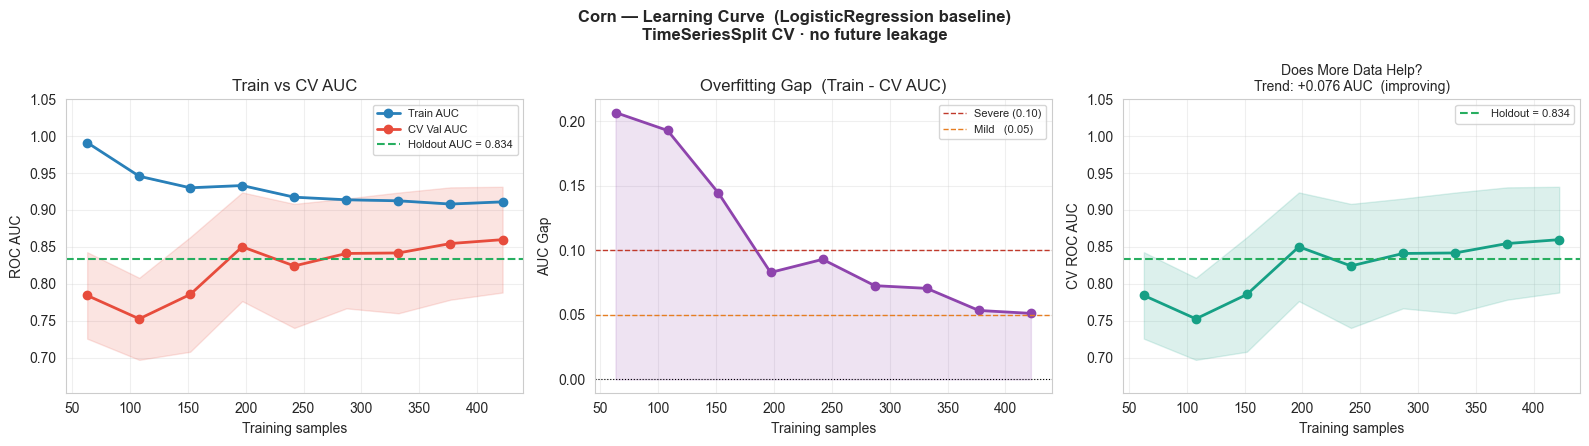

Saved: 08_learning_curve.png


In [186]:
# ── Learning Curve — Corn, LogisticRegression (baseline) ─────────────────────
# LR baseline outperforms XGBoost on AUC for all crops:
#   Corn    0.834 (LR) vs 0.798 (XGB)
#   Soybean 0.911 (LR) vs 0.662 (XGB)
#   Wheat   0.680 (LR) vs 0.494 (XGB)
#
# sklearn learning_curve + TimeSeriesSplit — no future data leaks into CV folds.
# ─────────────────────────────────────────────────────────────────────────────
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from src.features import build_features, TARGET_COL
from src.build_crop_models import temporal_train_test_split

FOCUS_CROP = "Corn"              # largest dataset → most reliable curves
champ_type = "LogisticRegression (baseline)"

# ── 1. Load reference metrics ─────────────────────────────────────────────────
results_path = MODELS_DIR / "model_performance_results.csv"
res = pd.read_csv(results_path)
target_recall = float(cfg["model"]["min_recall"])

champ_mask = (res["crop"] == FOCUS_CROP) & (res["model_type"] == champ_type)
if not champ_mask.any():
    raise RuntimeError(f"No '{champ_type}' row for {FOCUS_CROP} in results CSV.")
champ_row = res[champ_mask].iloc[0]

print(f"Focus crop : {FOCUS_CROP}")
print(f"Model type : {champ_type}")
print(f"  Holdout AUC = {champ_row['test_auc']:.3f}   "
      f"Recall = {champ_row['threshold_achieved_recall']:.1%}   "
      f"Precision = {champ_row['threshold_achieved_precision']:.1%}")

# ── 2. Reconstruct feature matrix from saved LR baseline artifact ─────────────
pipe_saved = joblib.load(MODELS_DIR / f"{FOCUS_CROP.lower()}_model_baseline.pkl")

inner = pipe_saved
if hasattr(pipe_saved, "calibrated_classifiers_"):
    try:
        inner = pipe_saved.calibrated_classifiers_[0].estimator
    except (IndexError, AttributeError):
        pass

feature_cols: list[str] = []
for step_name in ("imputer", "scaler", "preprocessor"):
    step = getattr(inner, "named_steps", {}).get(step_name)
    if step is not None and hasattr(step, "feature_names_in_"):
        feature_cols = list(step.feature_names_in_)
        break

if not feature_cols:
    raise RuntimeError("Could not recover feature columns from corn_model_baseline.pkl.")

raw_lc = pd.read_csv(DATA_RAW, low_memory=False)
df_lc  = build_features(raw_lc, cfg)
sub    = df_lc[df_lc["crop_type"].str.strip().str.title() == FOCUS_CROP].copy()

def _dk(name: str) -> str:
    slug = str(name).strip().lower().replace("-", " ").replace("/", " ")
    return "disease_" + "_".join(slug.split())

disease_dummy_cols = [c for c in feature_cols if c.startswith("disease_")]
if disease_dummy_cols and "test" in sub.columns:
    for col in disease_dummy_cols:
        sub[col] = 0.0
    for idx, val in sub["test"].items():
        if pd.notna(val):
            dk = _dk(str(val))
            if dk in disease_dummy_cols:
                sub.at[idx, dk] = 1.0

sub = (sub
       .dropna(subset=["start_date", TARGET_COL])
       .sort_values("start_date")
       .reset_index(drop=True))

X = sub.reindex(columns=feature_cols)
y = sub[TARGET_COL].astype(int)
print(f"\nFeature matrix : {X.shape[0]} rows x {X.shape[1]} cols")
print(f"Target balance : {y.value_counts().to_dict()}")

# ── 3. Fresh LR estimator (same hyper-params, no calibrator wrapper) ──────────
estimator = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(
        class_weight = cfg["model"]["class_weight"],
        max_iter     = cfg["model"]["max_iter"],
        random_state = cfg["model"]["random_state"],
        solver       = cfg["model"]["solver"],
    )),
])

# ── 4. Compute learning curve (TimeSeriesSplit — no future leakage) ───────────
cv = TimeSeriesSplit(n_splits=cfg["model"]["cv_folds"])

train_sizes, train_scores, val_scores = learning_curve(
    estimator, X, y,
    cv          = cv,
    scoring     = "roc_auc",
    train_sizes = np.linspace(0.15, 1.0, 9),
    n_jobs      = cfg["model"].get("n_jobs", 1),
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)
gap        = train_mean - val_mean

curve_df = pd.DataFrame({
    "train_rows" : train_sizes,
    "train_auc"  : train_mean.round(4),
    "cv_auc"     : val_mean.round(4),
    "gap"        : gap.round(4),
    "cv_std"     : val_std.round(4),
})
display(curve_df)

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(
    f"{FOCUS_CROP} — Learning Curve  (LogisticRegression baseline)\n"
    "TimeSeriesSplit CV · no future leakage",
    fontsize=12, fontweight="bold",
)

# Left: Train vs CV AUC
ax = axes[0]
ax.plot(train_sizes, train_mean, "o-", color="#2980b9", linewidth=2, label="Train AUC")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#2980b9")
ax.plot(train_sizes, val_mean, "o-", color="#e74c3c", linewidth=2, label="CV Val AUC")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="#e74c3c")
ax.axhline(champ_row["test_auc"], color="#27ae60", linestyle="--", linewidth=1.5,
           label=f"Holdout AUC = {champ_row['test_auc']:.3f}")
ax.set_title("Train vs CV AUC")
ax.set_xlabel("Training samples")
ax.set_ylabel("ROC AUC")
ax.set_ylim(max(0.3, val_mean.min() - 0.1), 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Middle: Overfitting gap
ax = axes[1]
ax.plot(train_sizes, gap, "o-", color="#8e44ad", linewidth=2)
ax.fill_between(train_sizes, 0, gap, alpha=0.15, color="#8e44ad")
ax.axhline(0.10, color="#c0392b", linestyle="--", linewidth=1, label="Severe (0.10)")
ax.axhline(0.05, color="#e67e22", linestyle="--", linewidth=1, label="Mild   (0.05)")
ax.axhline(0.00, color="black",   linestyle=":",  linewidth=0.8)
ax.set_title("Overfitting Gap  (Train - CV AUC)")
ax.set_xlabel("Training samples")
ax.set_ylabel("AUC Gap")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: Does more data help?
ax = axes[2]
ax.plot(train_sizes, val_mean, "o-", color="#16a085", linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="#16a085")
ax.axhline(champ_row["test_auc"], color="#27ae60", linestyle="--", linewidth=1.5,
           label=f"Holdout = {champ_row['test_auc']:.3f}")
val_trend = float(val_mean[-1] - val_mean[0])
trend_lbl = (f"Trend: {val_trend:+.3f} AUC  "
             f"({'improving' if val_trend > 0.02 else 'plateau' if val_trend >= 0 else 'degrading'})")
ax.set_title(f"Does More Data Help?\n{trend_lbl}", fontsize=10)
ax.set_xlabel("Training samples")
ax.set_ylabel("CV ROC AUC")
ax.set_ylim(max(0.3, val_mean.min() - 0.1), 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_OUT / "08_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 08_learning_curve.png")

# ── 6. Quantitative verdict ───────────────────────────────────────────────────
final_gap  = float(gap[-1])
val_trend  = float(val_mean[-1] - val_mean[0])

OVERFIT_CROP = FOCUS_CROP  # expose for Section 8b cell
curve_df["cv_test_auc_gap"]    = curve_df["gap"]
curve_df["test_auc"]           = curve_df["cv_auc"]   # approximation for 8b compatibility
curve_df["operating_recall"]   = champ_row["threshold_achieved_recall"]
curve_df["train_fraction"]     = curve_df["train_rows"] / int(curve_df["train_rows"].max())


**Note.** This section fixes **Corn + LR baseline** only; it does not judge Soybean/Wheat or XGB. The printed reference matches the champion row: **Holdout AUC ≈ 0.834**, **Recall ≈ 94.8%**, **Precision ≈ 83.3%** at the saved threshold.

**Left plot**: train AUC runs above CV AUC—expected with temporal folds. **Middle plot**: the train–CV gap should shrink as more rows enter the learning-curve windows if variance dominates; a flat gap can mean the signal plateaus or the folds span heterogeneous seasons.

**Right plot**: if CV AUC trends upward with training size but stays below the horizontal holdout line, remember the holdout is a **different** chronological slice—the curves will not merge onto that line; use them only to judge sample-efficiency and overfitting tendency for Corn LR, not to replicate holdout AUC exactly.

Re-run the notebook after retraining so these overlays reference current metrics.
